In [1]:
import numpy as np

In [2]:
import sequence_jacobian as sj
@sj.simple
def prod(A, K, L, alpha):
    Y = A * K(-1)**alpha * L**(1 - alpha)
    MPK = alpha * Y / K(-1)
    MPL = (1 - alpha) * Y / L
    return Y, MPK, MPL

In [3]:
print(prod), print(prod.outputs), print(prod.inputs)

<SimpleBlock 'prod'>
['Y', 'MPK', 'MPL']
['A', 'K', 'L', 'alpha']


(None, None, None)

In [4]:
calibration = {'A': 1, 'K': 4, 'L': 1, 'alpha': 0.3}
ss = prod.steady_state(calibration)
ss

<SteadyStateDict: ['A', 'K', 'L', 'alpha', 'Y', 'MPK', 'MPL']>

In [5]:
dict(**ss)

{'A': 1,
 'K': 4,
 'L': 1,
 'alpha': 0.3,
 'Y': 1.515716566510398,
 'MPK': 0.11367874248827985,
 'MPL': 1.0610015965572785}

In [6]:
ss = prod.solve_steady_state(calibration, 
            unknowns={'A':1., 'alpha': 0.5},
            targets={'Y': 1, 'MPK': 0.1})

In [7]:
dict(**ss)

{'A': np.float64(0.5743491774985149),
 'K': 4,
 'L': 1,
 'alpha': np.float64(0.40000000000002894),
 'Y': 1.0000000000000355,
 'MPK': 0.10000000000001079,
 'MPL': 0.5999999999999923}

In [8]:
J = prod.jacobian(ss, inputs=['K', 'L'],
                  outputs=['Y', 'MPL'])
J

<JacobianDict outputs=['Y', 'MPL'], inputs=['K', 'L']>

In [9]:
J['Y', 'K']

SimpleSparse({(-1, 0): 0.100})

In [10]:
J['Y', 'K'].matrix(5)

array([[0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0. ],
       [0. , 0.1, 0. , 0. , 0. ],
       [0. , 0. , 0.1, 0. , 0. ],
       [0. , 0. , 0. , 0.1, 0. ]])

In [11]:
dL = 0.5 * 0.9**np.arange(25)
dK = 2 * 0.5**np.arange(25)
impulse = J @ {'K': dK, 'L': dL}
impulse

<ImpulseDict: ['K', 'L', 'Y', 'MPL']>

In [12]:
impulse['K'][:5], impulse['Y'][:5]

(array([2.   , 1.   , 0.5  , 0.25 , 0.125]),
 array([0.3    , 0.47   , 0.343  , 0.2687 , 0.22183]))

In [13]:
impulse2 = prod.impulse_linear(ss, 
    inputs={'K': dK, 'L': dL}, outputs=['Y', 'MPL'])
impulse2['Y'][:5]

array([0.3    , 0.47   , 0.343  , 0.2687 , 0.22183])

In [14]:
impulse3 = prod.impulse_nonlinear(ss, 
    inputs={'K': dK, 'L': dL}, outputs=['Y', 'MPL'])
impulse3['Y'][:5]

array([0.2754245 , 0.46979683, 0.3408179 , 0.26312152, 0.21467539])

In [15]:
@sj.simple
def labor_supply(Lbar, w):
    L = Lbar * w**0.5
    return L

@sj.simple
def labor_mkt_clearing(w, MPL):
    labor_mkt = w - MPL
    return labor_mkt

model = sj.combine([prod, labor_supply, labor_mkt_clearing],
                   name='model')
model

<CombinedBlock 'model'>

In [16]:
print(model.blocks)
print(model.inputs)
print(model.outputs)

[<SimpleBlock 'labor_supply'>, <SimpleBlock 'prod'>, <SimpleBlock 'labor_mkt_clearing'>]
['A', 'K', 'alpha', 'Lbar', 'w']
['Y', 'MPK', 'MPL', 'L', 'labor_mkt']


In [17]:
ss = model.solve_steady_state(calibration,
        unknowns={'A': 1, 'alpha': 0.5, 'Lbar': 1, 'w': 1},
        targets={'Y': 1, 'L': 1, 'MPK': 0.1, 'labor_mkt': 0})
ss

<SteadyStateDict: ['A', 'K', 'L', 'alpha', 'Lbar', 'w', 'Y', 'MPK', 'MPL', 'labor_mkt']>

In [18]:
J = model.solve_jacobian(ss,
        inputs=['A', 'Lbar'], outputs=['Y', 'L', 'w'],
        unknowns=['w'], targets=['labor_mkt'], T=400)
J

<JacobianDict outputs=['w', 'Y', 'L'], inputs=['A', 'Lbar']>

In [19]:
J['Y', 'A'][:3, :3].round(3)

array([[2.176, 0.   , 0.   ],
       [0.   , 2.176, 0.   ],
       [0.   , 0.   , 2.176]])

In [20]:
Y_AL = prod.jacobian(ss, inputs=['L', 'A'], outputs=['Y'])
Y_A, Y_L = Y_AL['Y', 'A'], Y_AL['Y', 'L']
L_w = labor_supply.jacobian(ss, inputs=['w'], outputs=['L'])['L', 'w']
L_A = L_w @ J['w', 'A']
Y_AL = Y_L @ L_A + Y_A
Y_AL[:3, :3].round(3)

array([[2.176, 0.   , 0.   ],
       [0.   , 2.176, 0.   ],
       [0.   , 0.   , 2.176]])

In [21]:
hh = sj.hetblocks.hh_sim.hh


In [22]:
print(hh)
print(hh.inputs)
print(hh.outputs)

<HetBlock 'hh'>
['a_grid', 'y', 'r', 'beta', 'eis', 'Pi']
['A', 'C']


In [23]:
def income(e, Z):
    y = Z * e
    return y

hh = hh.add_hetinputs([income])
print(hh.inputs)

['a_grid', 'r', 'beta', 'eis', 'Pi', 'e', 'Z']


# Fiscal policy exercise

Define model with fiscal and market clearing blocks, taking same calibration as before:

In [24]:
@sj.simple
def fiscal(B, r, G, Y):
    T = (1 + r) * B(-1) + G - B
    Z = Y - T
    return T, Z

@sj.simple
def mkt_clearing(A, B, Y, C, G):
    asset_mkt = A - B
    goods_mkt = Y - C - G
    return asset_mkt, goods_mkt

model = sj.combine([hh, fiscal, mkt_clearing])

In [25]:
from calibration import make_calibration
calib, e = make_calibration(lowA=True)
calib.update({'e': e, 'B': 4,
              'T': 0.3, 'Y': 1,
              'G': 0.3 - calib['r']*4})

ss = model.steady_state(calib)
assert np.isclose(ss['asset_mkt'], 0, atol=1E-7)
assert np.isclose(ss['goods_mkt'], 0, atol=1E-7)

Also get the same dB and dT from that lecture (here we'll only need the dB), but scale by 5% on impact so that we have the same nonlinear shock as in lecture 3.

In [26]:
rho_B, rho = 0.975, 0.9
T = 400

dT_shock = -rho**np.arange(T)
dB = np.empty_like(dT_shock)
dB[0] = -dT_shock[0]
for t in range(1, T):
    dB[t] = rho_B * dB[t-1] - dT_shock[t]

dT = np.empty_like(dT_shock)
dT[0] = -dB[0]
dT[1:] = -dB[1:] + (1 + ss['r']) * dB[:-1]

In [27]:
dB, dT = 0.05*dB, 0.05*dT

Calculate response under asset market clearing:

In [ ]:
imp_linear = model.solve_impulse_linear(ss,
        unknowns=['Y'], targets=['asset_mkt'],
        inputs={'B': dB})
imp_linear['Y'][:5].round(3)

In [ ]:
imp_nonlin = model.solve_impulse_nonlinear(ss,
        unknowns=['Y'], targets=['asset_mkt'],
        inputs={'B': dB}, verbose=False)
imp_nonlin['Y'][:5].round(3)

array([0.041, 0.04 , 0.039, 0.038, 0.037])

Verify that it's the same as our alternative calculation:

In [ ]:
A = hh.jacobian(ss, inputs=['Z'],
                outputs=['A'], T=400)['A', 'Z']
dY = np.linalg.solve(A, dB) + dT
assert np.allclose(dY, imp_linear['Y'])

# Monetary policy exercise

In [ ]:
@sj.simple
def returns(r_ante):
    r = r_ante(-1)
    return r

@sj.simple
def fiscal(r_ante, G, Y):
    B = ss['B'] * (1 + ss['r']) / (1 + r_ante)
    T = (1 + r_ante(-1)) * B(-1) + G - B
    Z = Y - T
    return T, Z, B

model = sj.combine([returns, fiscal, mkt_clearing, hh])
ss = model.steady_state({**ss, 'r_ante': ss['r']})
assert np.isclose(ss['asset_mkt'], 0, atol=1E-7)
assert np.isclose(ss['goods_mkt'], 0, atol=1E-7)

In [ ]:
# scale shock as a 1pp (annualized) cut
# note vector "dr" from lecture 4 is dlog(1+r_ante)
dr = -0.0025 * 0.9**np.arange(T) / (1 + ss['r'])
imp_linear = model.solve_impulse_linear(ss,
                unknowns=['Y'], targets=['asset_mkt'],
                inputs={'r_ante': (1+ss['r'])*dr})
(imp_linear['Y'][:5]).round(3)

array([0.022, 0.02 , 0.018, 0.017, 0.015])

In [ ]:
imp_nonlin = model.solve_impulse_nonlinear(ss,
        unknowns=['Y'], targets=['asset_mkt'],
        inputs={'r_ante': (1+ss['r'])*dr}, verbose=False)
(imp_nonlin['Y'][:5]).round(3)

array([0.022, 0.02 , 0.018, 0.017, 0.015])

Verify that goods-space formula from lecture 4 holds:

In [ ]:
# Mr is direct effect of ex-ante dlog(1+r)
Mr = hh.jacobian(ss, inputs=['r'], outputs=['C'],
            T=401)['C', 'r'][:-1, 1:] * (1+ss['r'])
M = hh.jacobian(ss, inputs=['Z'], outputs=['C'],
            T=400)['C', 'Z']
dY = imp_linear['Y']
assert np.allclose(dY,
        Mr @ dr - ss['B'] * M @ dr + M @ dY)

# Fiscal policy extension with Taylor rule

In [ ]:
@sj.simple
def fiscal(B, r, G, Y):
    # note: taking B as exogenous again
    T = (1 + r) * B(-1) + G - B
    Z = Y - T
    return T, Z

beta_mean = ss['beta'].mean()
@sj.solved(unknowns={'pi': (-0.5, 0.5)},
           targets=['nkpc_resid'])
def pricing(pi, kappa, Y):
    nkpc_resid = (pi - kappa*(Y - ss['Y']) 
                            - beta_mean*pi(+1))
    return nkpc_resid

@sj.simple
def taylor(pi, phi_pi, r_ante):
    i = ss['r'] + phi_pi * pi
    r_resid = i - pi(+1) - r_ante
    return r_resid

In [ ]:
model = sj.combine([hh, returns, fiscal,
                    pricing, taylor, mkt_clearing])

ss = model.steady_state({**ss,
        'kappa': 0.01, 'phi_pi': 1.2})

dY_phi_12 = model.solve_impulse_linear(ss,
            unknowns=['Y', 'r_ante'],
            targets=['asset_mkt', 'r_resid'],
            inputs={'B': dB})['Y']

In [ ]:
# note: only edit steady state directly like this
# without recomputing if we're sure the parameter
# doesn't affect anything else in steady state, like here
ss['phi_pi'] = 2
dY_phi_2 = model.solve_impulse_linear(ss,
            unknowns=['Y', 'r_ante'],
            targets=['asset_mkt', 'r_resid'],
            inputs={'B': dB})['Y']

dY_original = np.linalg.solve(A, dB) + dT

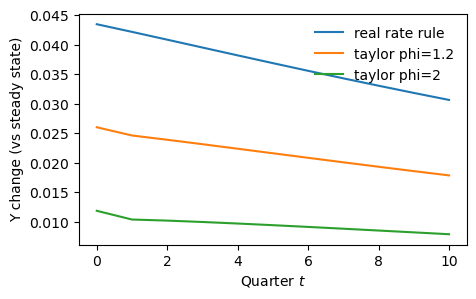

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(dY_original[:11], label='real rate rule')
plt.plot(dY_phi_12[:11], label='taylor phi=1.2')
plt.plot(dY_phi_2[:11], label='taylor phi=2')
plt.legend(frameon=False)
plt.xlabel('Quarter $t$')
plt.ylabel('Y change (vs steady state)')
plt.savefig("figures/lecture5_fig1.pdf", transparent=True,
            bbox_inches='tight')